# Compare regimes — thermal vs ASE

Side-by-side BER waterfalls, each vs its own bound (Forestieri A.19 for thermal, A.47 for ASE).
Same link, only the noise differs. Loads `results/pam4_<regime>.pt` (or trains it if missing).
The two bounds nearly coincide, so any extra distance on the ASE panel is the receiver, not the
noise. Run from `MLforCPO2`.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import sys
sys.path.insert(0, "functions")

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt

from config import Config
from train import train, evaluate
from utils import theoretical_ber_unipolar, theoretical_ber_unipolar_ase

%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"

WAVELENGTH = "oband"   # band for both panels: "oband" | "cband"
NUM_STEPS = 10000
NUM_EVAL = 400000
EBN0_DB = np.arange(6, 22, 2.0)

In [2]:
def load_or_train(regime):
    """Load results/pam4_<band>_<regime>.pt or train it from scratch (and cache it)."""
    config = Config()
    config.set_wavelength_band(WAVELENGTH)
    config.noise_regime = regime
    config.minibatch_symbols = 4096
    config.edge_guard_symbols = 48
    path = os.path.join("results", f"pam4_{WAVELENGTH}_{regime}.pt")
    if os.path.exists(path):
        print(f"[{WAVELENGTH}/{regime}] loading {path}")
        ckpt = torch.load(path, weights_only=False, map_location=device)
        return np.asarray(ckpt["ebn0_db"]), np.asarray(ckpt["measured"])
    print(f"[{WAVELENGTH}/{regime}] no checkpoint -> training from scratch")
    torch.manual_seed(0)
    np.random.seed(0)
    transmitter, channel, receiver = train(config, device, num_steps=NUM_STEPS)
    measured = evaluate(transmitter, channel, receiver, config, EBN0_DB, NUM_EVAL, device)
    os.makedirs("results", exist_ok=True)
    torch.save({"transmitter": transmitter.state_dict(), "receiver": receiver.state_dict(),
                "config": {k: v for k, v in vars(config).items()},
                "wavelength_band": config.wavelength_band,
                "optical_filter_type": channel.optical_filter_type,
                "ebn0_db": EBN0_DB, "measured": measured}, path)
    print(f"[{WAVELENGTH}/{regime}] saved {path}")
    return EBN0_DB, measured

[oband/thermal] loading results\pam4_oband_thermal.pt
[oband/ase] loading results\pam4_oband_ase.pt


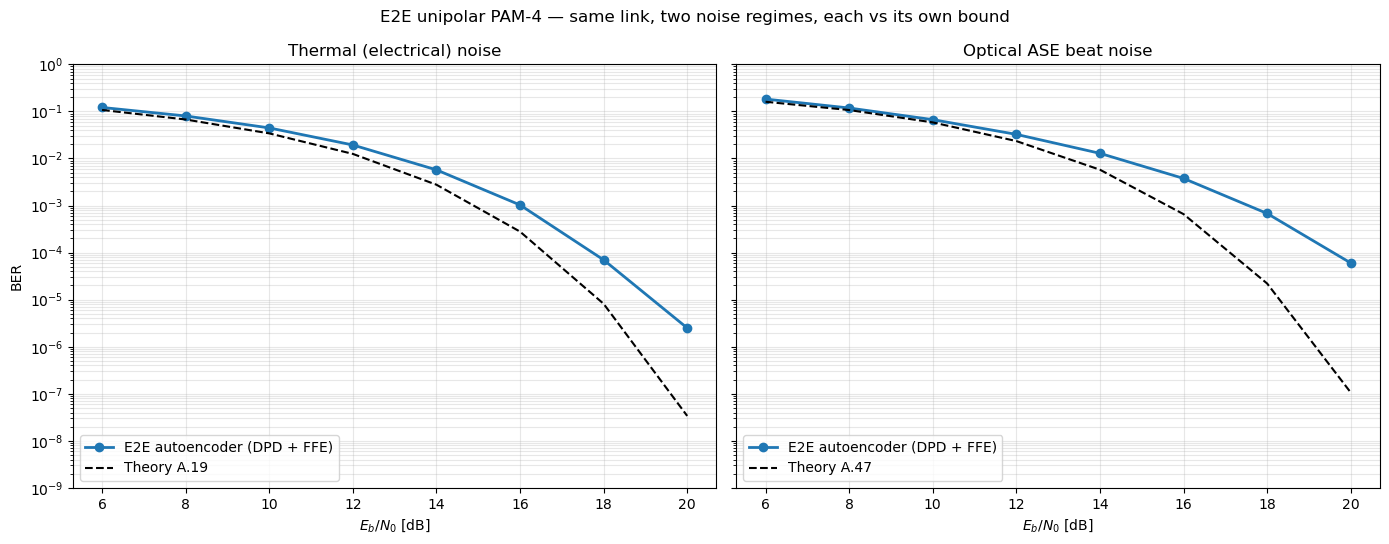


  Eb/N0       thermal E2E       ASE E2E
    6.0       1.213e-01        1.827e-01
    8.0       8.001e-02        1.181e-01
   10.0       4.456e-02        6.679e-02
   12.0       1.934e-02        3.249e-02
   14.0       5.726e-03        1.285e-02
   16.0       1.028e-03        3.767e-03
   18.0       7.002e-05        6.780e-04
   20.0       2.501e-06        6.015e-05


In [3]:
panels = [
    ("thermal", theoretical_ber_unipolar, "Thermal (electrical) noise", "Theory A.19"),
    ("ase", theoretical_ber_unipolar_ase, "Optical ASE beat noise", "Theory A.47"),
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
rows = {}
for ax, (regime, theory_fn, title, theory_label) in zip(axes, panels):
    ebn0_db, measured = load_or_train(regime)
    theory = theory_fn(ebn0_db, 4)
    floor = np.maximum(measured, 1.0 / NUM_EVAL)
    ax.semilogy(ebn0_db, floor, "-o", linewidth=2, label="E2E autoencoder (DPD + FFE)")
    ax.semilogy(ebn0_db, theory, "k--", linewidth=1.5, label=theory_label)
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"$E_b/N_0$ [dB]")
    ax.set_ylim(1e-9, 1)
    ax.set_title(title)
    ax.legend(loc="lower left")
    rows[regime] = measured
axes[0].set_ylabel("BER")
fig.suptitle("E2E unipolar PAM-4 — same link, two noise regimes, each vs its own bound")
fig.tight_layout()
fig.savefig(os.path.join("results", "pam4_regime_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\n  Eb/N0       thermal E2E       ASE E2E")
for e, m_th, m_ase in zip(EBN0_DB, rows["thermal"], rows["ase"]):
    print(f"  {e:5.1f}       {m_th:.3e}        {m_ase:.3e}")